In [20]:
#@title 📦 Kaggle Competition Loader { display-mode: "form" }
#@markdown ---
#@markdown ### How to use
#@markdown 1. Run this cell (code stays hidden — double-click the title to peek).
#@markdown 2. When prompted, paste the **full Kaggle competition URL**
#@markdown    (e.g. `https://www.kaggle.com/c/titanic`) — or just the slug.
#@markdown 3. Make sure you're authenticated with `kagglehub` (it'll prompt on first run).
#@markdown 4. After it finishes, your data is available as:
#@markdown    - `data['train.csv']`, `data['test.csv']`, etc. → pandas DataFrames
#@markdown    - `data['some_file.ext']` → file path (non-CSV files)
#@markdown    - `data_dir` → the local folder containing everything
#@markdown ---

import os
import re
import shutil
import kagglehub
import pandas as pd


def _extract_slug(text: str) -> str:
    """Pulls the competition slug out of a full URL or accepts a bare slug."""
    text = text.strip().rstrip('/')
    match = re.search(r'kaggle\.com/(?:c|competitions)/([^/?#]+)', text)
    if match:
        return match.group(1)
    if "kaggle.com" in text:
        return text.split('/')[-1]
    return text


def fetch_kaggle_competition(comp_url: str = None, copy_to_local: bool = True):
    """
    Downloads a Kaggle competition dataset via kagglehub and loads all CSVs.

    Args:
        comp_url: Full Kaggle competition URL or slug. If None, you'll be prompted.
        copy_to_local: If True, copies files out of the kagglehub cache into ./<slug>/

    Returns:
        data: dict mapping filename -> DataFrame (for .csv) or filepath (other files)
        working_path: directory containing the dataset files
    """
    comp_input = comp_url or input("Paste Kaggle competition URL (or slug): ").strip()
    comp_id = _extract_slug(comp_input)

    if not comp_id:
        raise ValueError("Could not parse a competition slug from that input.")

    print(f"\n[1/3] Authenticating & downloading: '{comp_id}'...")
    kagglehub.login()
    cache_path = kagglehub.competition_download(comp_id)

    target_dir = os.path.join(os.getcwd(), comp_id)
    if copy_to_local:
        if os.path.exists(target_dir):
            shutil.rmtree(target_dir)
        shutil.copytree(cache_path, target_dir)
        working_path = target_dir
    else:
        working_path = cache_path

    print(f"[2/3] Files localized to: {working_path}")

    data = {}
    print("\n[3/3] Inspecting dataset contents:")
    for root, _, filenames in os.walk(working_path):
        for fname in sorted(filenames):
            fpath = os.path.join(root, fname)
            if fname.endswith('.csv'):
                data[fname] = pd.read_csv(fpath)
                print(f"  • {fname:30s} shape={data[fname].shape} -> data['{fname}']")
            else:
                data[fname] = fpath
                print(f"  • {fname:30s} (path saved) -> data['{fname}']")

    return data, working_path


# ==========================================
# RUN — paste your competition URL when asked
# ==========================================
data, data_dir = fetch_kaggle_competition()
print("\nAvailable keys:", list(data.keys()))

Enter Kaggle Competition Slug (from URL): store-sales-time-series-forecasting

[1/3] Authenticating & Downloading: 'store-sales-time-series-forecasting'...


100%|██████████| 21.4M/21.4M [00:00<00:00, 95.7MB/s]

Extracting files...


[2/3] Files localized to: /content/store-sales-time-series-forecasting

[3/3] Inspecting downloaded dataset contents:
  • stores.csv (Loaded -> access via data['stores.csv'])
  • sample_submission.csv (Loaded -> access via data['sample_submission.csv'])
  • test.csv (Loaded -> access via data['test.csv'])
  • train.csv (Loaded -> access via data['train.csv'])
  • oil.csv (Loaded -> access via data['oil.csv'])
  • holidays_events.csv (Loaded -> access via data['holidays_events.csv'])
  • transactions.csv (Loaded -> access via data['transactions.csv'])

Available data keys: ['stores.csv', 'sample_submission.csv', 'test.csv', 'train.csv', 'oil.csv', 'holidays_events.csv', 'transactions.csv']


# 1. Load & merge

In [21]:
import pandas as pd
import numpy as np

train = data['train.csv'].copy()
test = data['test.csv'].copy()
stores = data['stores.csv'].copy()
oil = data['oil.csv'].copy()
holidays = data['holidays_events.csv'].copy()
transactions = data['transactions.csv'].copy()

for df in [train, test, oil, holidays, transactions]:
    df['date'] = pd.to_datetime(df['date'])

# Because per-row regression on ~3M raw rows is unwieldy for Simple/Multiple/Poly
# regression demos, aggregate to daily total sales across all stores/families.
daily = train.groupby('date').agg(
    sales=('sales', 'sum'),
    onpromotion=('onpromotion', 'sum')
).reset_index()

# 2. EDA

date           0
sales          0
onpromotion    0
dtype: int64
date           0
dcoilwtico    43
dtype: int64


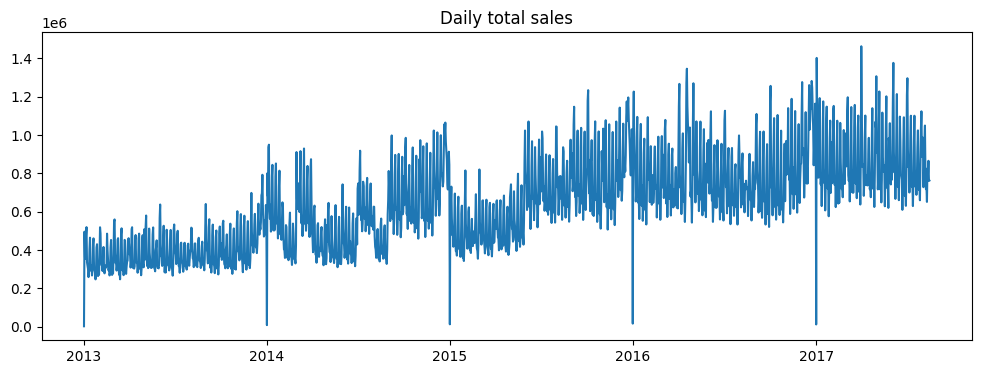

                sales  onpromotion  dcoilwtico  is_holiday  dayofweek  \
sales        1.000000     0.574943   -0.626889    0.108702   0.308960   
onpromotion  0.574943     1.000000   -0.621498    0.058637  -0.010838   
dcoilwtico  -0.626889    -0.621498    1.000000   -0.024650   0.002955   
is_holiday   0.108702     0.058637   -0.024650    1.000000   0.000609   
dayofweek    0.308960    -0.010838    0.002955    0.000609   1.000000   
day_index    0.718394     0.829010   -0.838830    0.033880  -0.001560   

             day_index  
sales         0.718394  
onpromotion   0.829010  
dcoilwtico   -0.838830  
is_holiday    0.033880  
dayofweek    -0.001560  
day_index     1.000000  


In [22]:
# Missing values
print(daily.isnull().sum())
print(oil.isnull().sum())          # oil has gaps on non-trading days

# Fill oil gaps (common approach: forward-fill then back-fill)
oil['dcoilwtico'] = oil['dcoilwtico'].ffill().bfill()

# Merge oil price + a holiday flag onto daily sales
daily = daily.merge(oil, on='date', how='left')
daily['dcoilwtico'] = daily['dcoilwtico'].ffill().bfill()

holiday_dates = set(holidays.loc[holidays['transferred']==False, 'date'])
daily['is_holiday'] = daily['date'].isin(holiday_dates).astype(int)

# Date-derived features
daily['dayofweek'] = daily['date'].dt.dayofweek
daily['month'] = daily['date'].dt.month
daily['day_index'] = (daily['date'] - daily['date'].min()).dt.days  # trend feature

# Outlier check (e.g. Dec holidays spike, earthquake April 2016)
import matplotlib.pyplot as plt
plt.figure(figsize=(12,4)); plt.plot(daily['date'], daily['sales']); plt.title('Daily total sales'); plt.show()

# Correlation
print(daily[['sales','onpromotion','dcoilwtico','is_holiday','dayofweek','day_index']].corr())

# 3. Three regression models

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

X_simple = daily[['day_index']]
X_multi  = daily[['day_index','onpromotion','dcoilwtico','is_holiday','dayofweek']]
y = daily['sales']

Xs_tr, Xs_te, y_tr, y_te = train_test_split(X_simple, y, test_size=0.2, shuffle=False)
Xm_tr, Xm_te, _, _       = train_test_split(X_multi,  y, test_size=0.2, shuffle=False)

# 1. Simple Linear Regression
simple = LinearRegression().fit(Xs_tr, y_tr)
pred_s = simple.predict(Xs_te)

# 2. Multiple Linear Regression
multi = LinearRegression().fit(Xm_tr, y_tr)
pred_m = multi.predict(Xm_te)

# 3. Polynomial Regression (on day_index, degree 3 as a start)
poly = PolynomialFeatures(degree=3)
Xp_tr = poly.fit_transform(Xs_tr)
Xp_te = poly.transform(Xs_te)
polyreg = LinearRegression().fit(Xp_tr, y_tr)
pred_p = polyreg.predict(Xp_te)

for name, pred in [('Simple', pred_s), ('Multiple', pred_m), ('Polynomial', pred_p)]:
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    print(f"{name}: RMSE={rmse:.2f}, R2={r2_score(y_te, pred):.3f}")

Simple: RMSE=194319.64, R2=-0.096
Multiple: RMSE=166430.49, R2=0.196
Polynomial: RMSE=204457.71, R2=-0.213


# 4. build test dat features

In [25]:
# Test set covers a future date range with no `sales` column
test_daily = test.groupby('date').agg(onpromotion=('onpromotion', 'sum')).reset_index()

# Oil: merge + fill (oil.csv should cover the test date range too)
test_daily = test_daily.merge(oil, on='date', how='left')
test_daily['dcoilwtico'] = test_daily['dcoilwtico'].ffill().bfill()
# in case test oil values are still missing at the start, backfill from train's last known value
test_daily['dcoilwtico'] = test_daily['dcoilwtico'].fillna(daily['dcoilwtico'].iloc[-1])

test_daily['is_holiday'] = test_daily['date'].isin(holiday_dates).astype(int)
test_daily['dayofweek'] = test_daily['date'].dt.dayofweek
test_daily['month'] = test_daily['date'].dt.month
# day_index must continue the SAME numbering scheme as train
test_daily['day_index'] = (test_daily['date'] - daily['date'].min()).dt.days

# 5. Refit each model on the FULL daily history (not just the train-split portion)

In [27]:
from sklearn.preprocessing import StandardScaler
X_simple_full = daily[['day_index']]
X_multi_full  = daily[['day_index','onpromotion','dcoilwtico','is_holiday','dayofweek']]
y_full = daily['sales']

simple_final = LinearRegression().fit(X_simple_full, y_full)
multi_final  = LinearRegression().fit(X_multi_full, y_full)

scaler_final = StandardScaler().fit(X_simple_full)
poly_final = PolynomialFeatures(degree=3)
Xp_full = poly_final.fit_transform(scaler_final.transform(X_simple_full))
polyreg_final = LinearRegression().fit(Xp_full, y_full)

# Predict daily TOTAL sales for every test date
test_daily['pred_simple'] = simple_final.predict(test_daily[['day_index']])
test_daily['pred_multi']  = multi_final.predict(test_daily[['day_index','onpromotion','dcoilwtico','is_holiday','dayofweek']])
test_daily['pred_poly']   = polyreg_final.predict(poly_final.transform(scaler_final.transform(test_daily[['day_index']])))

# Sales can't be negative
for col in ['pred_simple','pred_multi','pred_poly']:
    test_daily[col] = test_daily[col].clip(lower=0)

# 6. Compute each (store, family) group's historical share of the daily total

In [28]:
group_totals = train.groupby(['date','store_nbr','family'])['sales'].sum().reset_index()
group_totals = group_totals.merge(
    train.groupby('date')['sales'].sum().rename('day_total'), on='date'
)
group_totals['share'] = group_totals['sales'] / group_totals['day_total'].replace(0, np.nan)

# Average share per (store_nbr, family) across all of train — this is what we'll apply to test
avg_share = group_totals.groupby(['store_nbr','family'])['share'].mean().reset_index()
avg_share['share'] = avg_share['share'].fillna(0)
# normalize so shares sum to 1 per day (guards against rounding drift)
avg_share['share'] = avg_share['share'] / avg_share['share'].sum()

# 7. Distribute predictions onto test rows and write out three submission files

In [29]:
test_merged = test.merge(test_daily[['date','pred_simple','pred_multi','pred_poly']], on='date', how='left')
test_merged = test_merged.merge(avg_share, on=['store_nbr','family'], how='left')
test_merged['share'] = test_merged['share'].fillna(0)

for model_col, filename in [('pred_simple','submission_simple.csv'),
                             ('pred_multi','submission_multiple.csv'),
                             ('pred_poly','submission_polynomial.csv')]:
    test_merged['sales'] = (test_merged[model_col] * test_merged['share']).clip(lower=0)
    submission = test_merged[['id','sales']]
    submission.to_csv(filename, index=False)
    print(f"Saved {filename} — {submission.shape[0]} rows, sample:\n{submission.head(2)}\n")

Saved submission_simple.csv — 28512 rows, sample:
        id     sales
0  3000888  5.108971
1  3000889  0.000000

Saved submission_multiple.csv — 28512 rows, sample:
        id     sales
0  3000888  4.594735
1  3000889  0.000000

Saved submission_polynomial.csv — 28512 rows, sample:
        id     sales
0  3000888  4.731175
1  3000889  0.000000



In [36]:
sample = data['sample_submission.csv']
print((sub['id'].values == sample['id'].values).all())   # True if row order/ids match exactly

True


In [37]:
sub['id'] = sub['id'].astype(int)
sub.to_csv('submission_polynomial.csv', index=False)

In [38]:
#@title Submit predictions to Kaggle { display-mode: "form" }
#@markdown Reads Kaggle credentials from Colab secrets, validates each
#@markdown `submission_*.csv` against `sample_submission.csv`, then asks
#@markdown for a per-file y/n confirmation before submitting.
#@markdown
#@markdown ⚠️ **Most Kaggle competitions cap you at 5 submissions/day.**
#@markdown Check the "My Submissions" tab on the competition page for
#@markdown your remaining count before confirming each file — a 400/403
#@markdown error with no other obvious cause usually means you hit the cap.
#@markdown
#@markdown Assumes the Kaggle Competition Loader cell has already run
#@markdown (uses its `data` and `data_dir` globals).

from google.colab import userdata
import os, glob, pandas as pd

os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_LEGACY_KEY')

COMP = os.path.basename(data_dir)   # slug taken from the loader cell, no re-entry needed
sample = data['sample_submission.csv']

for path in sorted(glob.glob("submission_*.csv")):
    sub = pd.read_csv(path)
    ok = (sub.shape == sample.shape
          and list(sub.columns) == list(sample.columns)
          and sub['id'].astype(int).equals(sample['id'].astype(int))
          and sub.isna().sum().sum() == 0)
    print(f"\n{path}: {'OK' if ok else 'MISMATCH'} — shape {sub.shape}, dtypes {dict(sub.dtypes)}")
    if not ok:
        print("  Skipping — fix the file before submitting.")
        continue
    if input(f"Submit {path}? (y/n): ").strip().lower() == 'y':
        msg = input("  Submission message: ").strip() or path
        os.system(f'kaggle competitions submit -c {COMP} -f {path} -m "{msg}"')

100% 727k/727k [00:00<00:00, 3.57MB/s]
400 Client Error: Bad Request for url: https://api.kaggle.com/v1/competitions.CompetitionApiService/CreateSubmission
100% 726k/726k [00:00<00:00, 3.24MB/s]
400 Client Error: Bad Request for url: https://api.kaggle.com/v1/competitions.CompetitionApiService/CreateSubmission
100% 722k/722k [00:00<00:00, 3.79MB/s]
400 Client Error: Bad Request for url: https://api.kaggle.com/v1/competitions.CompetitionApiService/CreateSubmission


## Submission Requirements
1. [store sales time series forecasting](https://www.kaggle.com/competitions/store-sales-time-series-forecasting/submissions)


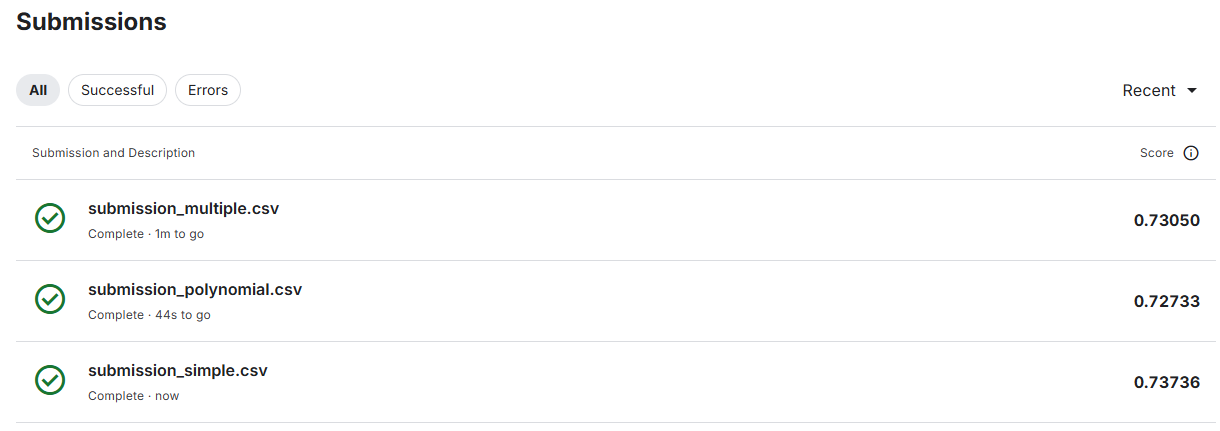